# Configuración Global e Imports

In [14]:
# ==========================================
# CELDA 1: IMPORTS Y CONFIGURACIÓN GLOBAL
# ==========================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

# Importamos Pipeline de imblearn para evitar data leakage en CV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import ADASYN

# --- VARIABLES GLOBALES DE EXPERIMENTACIÓN ---
WINDOW = 30               # Días de datos a observar (ej. 30, 60, 90)
SAMPLING = "Undersampling"       # Opciones: "ADASYN", "Undersampling", "None"
USE_PRIVATE_INFO = True   # True: Usa demografía | False: Solo interacciones

RUTA_ORIGEN = './../../dataset/oulad/'
RUTA_DESTINO = f'./../../dataset/oulad/generated_{WINDOW}d'

print(f"Configuración cargada: Ventana={WINDOW}d | Balanceo={SAMPLING} | Privacidad={USE_PRIVATE_INFO}")

Configuración cargada: Ventana=30d | Balanceo=Undersampling | Privacidad=True


# Generador de Dataset Dinámico

In [15]:
# ==========================================
# CELDA 2: MOTOR DE EXTRACCIÓN ENRIQUECIDO DINÁMICO
# ==========================================
def crear_dataset_enriquecido(ruta_base_datos, ruta_salida, dias_ventana):
    print(f"Iniciando generación del dataset enriquecido a {dias_ventana} días...")

    info_df = pd.read_csv(os.path.join(ruta_base_datos, 'studentInfo.csv'))
    vle_df = pd.read_csv(os.path.join(ruta_base_datos, 'studentVle.csv'))
    assessments = pd.read_csv(os.path.join(ruta_base_datos, 'assessments.csv'))
    student_assessment = pd.read_csv(os.path.join(ruta_base_datos, 'studentAssessment.csv'))
    registration = pd.read_csv(os.path.join(ruta_base_datos, 'studentRegistration.csv'))

    modulos_objetivo = ['BBB', 'DDD', 'FFF']
    info_df = info_df[info_df['code_module'].isin(modulos_objetivo)]

    # Mantenemos las columnas sensibles en el maestro, luego decidimos si usarlas
    # -------------------------------------------------------------
    # PROCESAMIENTO VLE
    vle_window = vle_df[vle_df['date'] <= dias_ventana].copy()
    vle_window['week'] = (vle_window['date'] // 7).clip(lower=0)

    vle_diario = vle_window.groupby(['id_student', 'code_module', 'code_presentation', 'week', 'date'])['sum_click'].sum().reset_index()
    max_clicks_dia = vle_diario.groupby(['id_student', 'code_module', 'code_presentation'])['sum_click'].max().rename('max_clicks_1_dia').reset_index()

    vle_semanal = vle_diario.groupby(['id_student', 'code_module', 'code_presentation', 'week']).agg(
        clicks_semanales=('sum_click', 'sum'),
        dias_activos_semana=('date', 'nunique')
    ).reset_index()

    vle_semanas_pivot = vle_semanal.pivot_table(index=['id_student', 'code_module', 'code_presentation'], columns='week', values='clicks_semanales', fill_value=0).reset_index()
    nombres_semanas = {col: f'clicks_semana_{int(col)}' for col in vle_semanas_pivot.columns if isinstance(col, (int, float))}
    vle_semanas_pivot = vle_semanas_pivot.rename(columns=nombres_semanas)
    lista_columnas_semanales = list(nombres_semanas.values())

    vle_features = vle_semanal.groupby(['id_student', 'code_module', 'code_presentation']).agg(
        total_clicks_window=('clicks_semanales', 'sum'),
        media_clicks_semanales=('clicks_semanales', 'mean'),
        total_dias_activos=('dias_activos_semana', 'sum'),
        semanas_con_actividad=('week', 'nunique'),
        semanas_actividad_plena=('dias_activos_semana', lambda x: (x >= 5).sum())
    ).reset_index()

    TOTAL_SEMANAS = (dias_ventana // 7) + 1
    vle_features['semanas_sin_clicks'] = TOTAL_SEMANAS - vle_features['semanas_con_actividad']
    vle_features['dias_sin_clicks_window'] = dias_ventana - vle_features['total_dias_activos']

    vle_features = pd.merge(vle_features, max_clicks_dia, on=['id_student', 'code_module', 'code_presentation'], how='left')
    vle_features = pd.merge(vle_features, vle_semanas_pivot, on=['id_student', 'code_module', 'code_presentation'], how='left')

    # -------------------------------------------------------------
    # PROCESAMIENTO ASSESSMENTS
    assessments['date'] = pd.to_numeric(assessments['date'].replace('?', np.nan))
    assessments_window = assessments[assessments['date'] <= dias_ventana].copy()
    student_ass_window = pd.merge(student_assessment, assessments_window, on='id_assessment', how='inner')

    student_ass_window['date_submitted'] = pd.to_numeric(student_ass_window['date_submitted'], errors='coerce')
    student_ass_window['retraso_dias'] = student_ass_window['date_submitted'] - student_ass_window['date']
    student_ass_window['es_entrega_tardia'] = (student_ass_window['retraso_dias'] > 0).astype(int)
    student_ass_window['score'] = pd.to_numeric(student_ass_window['score'], errors='coerce')

    ass_features = student_ass_window.groupby(['id_student', 'code_module', 'code_presentation']).agg(
        entregas_realizadas_window=('id_assessment', 'count'),
        nota_media_window=('score', 'mean'),
        retraso_medio_dias=('retraso_dias', 'mean'),
        total_entregas_tardias=('es_entrega_tardia', 'sum')
    ).reset_index()

    # -------------------------------------------------------------
    # REGISTRO Y CONSOLIDACIÓN
    reg_features = registration[['id_student', 'code_module', 'code_presentation', 'date_registration']].copy()
    reg_features['date_registration'] = pd.to_numeric(reg_features['date_registration'].replace('?', np.nan))

    df_master = info_df.copy()
    df_master = pd.merge(df_master, vle_features, on=['id_student', 'code_module', 'code_presentation'], how='left')
    df_master = pd.merge(df_master, ass_features, on=['id_student', 'code_module', 'code_presentation'], how='left')
    df_master = pd.merge(df_master, reg_features, on=['id_student', 'code_module', 'code_presentation'], how='left')

    columnas_a_rellenar = [
        'total_clicks_window', 'media_clicks_semanales', 'total_dias_activos', 'semanas_con_actividad',
        'semanas_actividad_plena', 'max_clicks_1_dia', 'entregas_realizadas_window',
        'nota_media_window', 'retraso_medio_dias', 'total_entregas_tardias'
    ] + lista_columnas_semanales

    df_master[columnas_a_rellenar] = df_master[columnas_a_rellenar].fillna(0)
    df_master['semanas_sin_clicks'] = df_master['semanas_sin_clicks'].fillna(TOTAL_SEMANAS)
    df_master['dias_sin_clicks_window'] = df_master['dias_sin_clicks_window'].fillna(dias_ventana)

    df_master['target_burnout'] = df_master['final_result'].apply(lambda x: 1 if x == 'Withdrawn' else 0)
    df_master.drop(columns=['final_result', 'id_student'], inplace=True)

    if not os.path.exists(ruta_salida):
        os.makedirs(ruta_salida)

    df_train = df_master[df_master['code_presentation'].str.contains('2013')].copy()
    df_test = df_master[df_master['code_presentation'].str.contains('2014')].copy()

    df_train.drop(columns=['code_module', 'code_presentation'], inplace=True)
    df_test.drop(columns=['code_module', 'code_presentation'], inplace=True)

    archivo_train = os.path.join(ruta_salida, 'dataset_train_2013.csv')
    archivo_test = os.path.join(ruta_salida, 'dataset_test_2014.csv')

    df_train.to_csv(archivo_train, index=False)
    df_test.to_csv(archivo_test, index=False)
    print(f"Dataset generado exitosamente en {ruta_salida}.")

# Ejecutar generador si no existen los datos
if not os.path.exists(RUTA_DESTINO):
    crear_dataset_enriquecido(RUTA_ORIGEN, RUTA_DESTINO, WINDOW)
else:
    print(f"Los datos para la ventana de {WINDOW} días ya existen. Saltando generación.")

Los datos para la ventana de 30 días ya existen. Saltando generación.


# Carga, Preprocesamiento Dinámico y GridSearch

In [16]:
# ==========================================
# CELDA 3: CARGA DE DATOS Y OPTIMIZACIÓN (GRID SEARCH)
# ==========================================
import os
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SklearnPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
from imblearn.under_sampling import RandomUnderSampler
import xgboost as xgb
from sklearn.model_selection import GridSearchCV

# 1. Cargar datos
df_train = pd.read_csv(os.path.join(RUTA_DESTINO, 'dataset_train_2013.csv'))
df_test = pd.read_csv(os.path.join(RUTA_DESTINO, 'dataset_test_2014.csv'))

columnas_sensibles = ['gender', 'region', 'imd_band', 'age_band', 'disability']
if not USE_PRIVATE_INFO:
    df_train.drop(columns=columnas_sensibles, inplace=True, errors='ignore')
    df_test.drop(columns=columnas_sensibles, inplace=True, errors='ignore')

# 2. Separar características (X) y variable objetivo (y)
X_train = df_train.drop(columns=['target_burnout'])
y_train = df_train['target_burnout']
X_test = df_test.drop(columns=['target_burnout'])
y_test = df_test['target_burnout']

# 3. Detectar dinámicamente columnas categóricas y numéricas
# CORRECCIÓN: Añadimos 'str' para silenciar el Pandas4Warning
cat_cols = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# CORRECCIÓN: Creamos sub-pipelines con SimpleImputer para erradicar los NaNs
num_pipeline = SklearnPipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)), # Rellena numéricos nulos con 0
    ('scaler', StandardScaler())
])

cat_pipeline = SklearnPipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # Rellena categóricos nulos con la moda
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# 4. Configurar el Sampler
sampler = None
if SAMPLING == "ADASYN":
    sampler = ADASYN(random_state=42, n_neighbors=5)
elif SAMPLING == "Undersampling":
    sampler = RandomUnderSampler(random_state=42)

# 5. Crear ImbPipeline
pasos = [('preprocessor', preprocessor)]
if sampler is not None:
    pasos.append(('sampler', sampler))

# Si aplicamos remuestreo, el modelo ve clases balanceadas, scale_pos_weight = 1
# Si no, calculamos el peso dinámicamente
peso = 1 if SAMPLING != "None" else float(y_train.value_counts()[0]) / y_train.value_counts()[1]

pasos.append(('classifier', xgb.XGBClassifier(
    eval_metric='logloss',
    scale_pos_weight=peso,
    random_state=42,
    n_jobs=-1
)))

pipeline = ImbPipeline(pasos)

# 6. Espacio de Búsqueda
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__min_child_weight': [1, 5, 10]
}

print(f"Iniciando Grid Search (Métrica: F1, Sampler: {SAMPLING})...")
grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, scoring='f1', cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

mejor_modelo = grid_search.best_estimator_
print("\n" + "=" * 50)
print("¡BÚSQUEDA FINALIZADA!")
print("Mejores hiperparámetros encontrados:")
for param, value in grid_search.best_params_.items():
    print(f" - {param.replace('classifier__', '')}: {value}")
print("=" * 50)

Iniciando Grid Search (Métrica: F1, Sampler: Undersampling)...
Fitting 3 folds for each of 144 candidates, totalling 432 fits

¡BÚSQUEDA FINALIZADA!
Mejores hiperparámetros encontrados:
 - learning_rate: 0.01
 - max_depth: 3
 - min_child_weight: 1
 - n_estimators: 50


# Evaluación y Calibración de Umbral

--- REPORTE DEL MEJOR MODELO (Umbral: 0.5) ---
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      7108
           1       0.68      0.65      0.66      3693

    accuracy                           0.77     10801
   macro avg       0.75      0.74      0.74     10801
weighted avg       0.77      0.77      0.77     10801



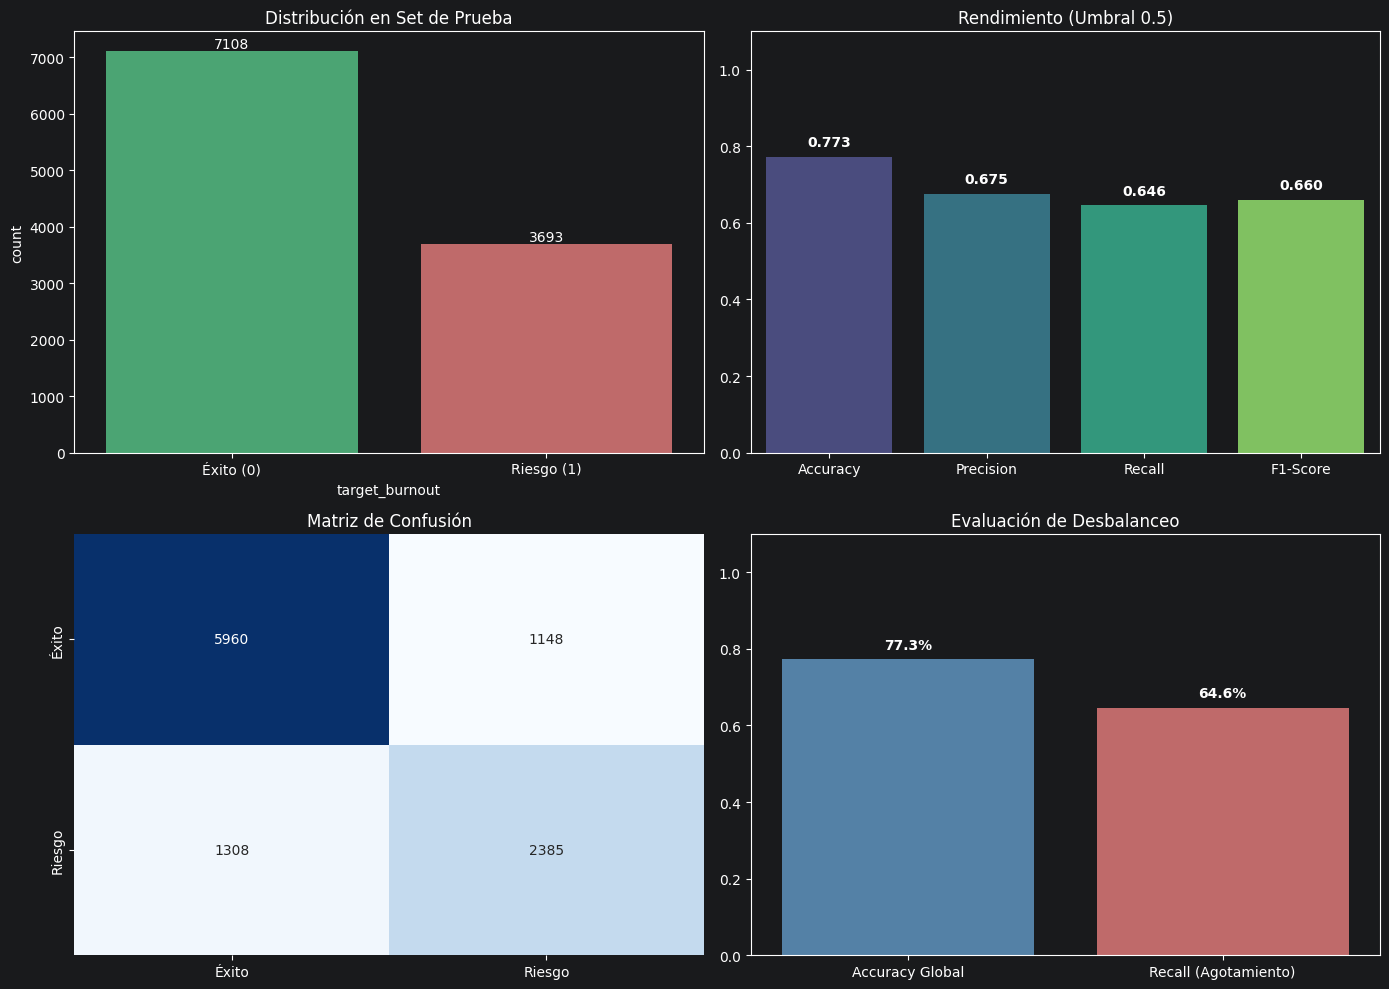

 BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO GANADOR
Umbral   | Accuracy Global    | Recall (Riesgo)    | Precisión (Riesgo)
-----------------------------------------------------------------
0.30     |  34.2%             | 100.0%             |  34.2%
0.35     |  34.2%             | 100.0%             |  34.2%
0.40     |  46.7%             |  95.7%             |  38.7%
0.45     |  73.8%             |  72.3%             |  59.7%
0.50     |  77.3%             |  64.6%             |  67.5%
0.55     |  77.7%             |  62.1%             |  69.3%
0.60     |  78.2%             |  60.5%             |  71.5%
0.65     |  76.9%             |  35.6%             |  91.8%
0.70     |  65.8%             |   0.0%             |   0.0%
0.75     |  65.8%             |   0.0%             |   0.0%
0.80     |  65.8%             |   0.0%             |   0.0%


In [17]:
# ==========================================
# CELDA 4: EVALUACIÓN Y GRÁFICAS
# ==========================================
# 1. Obtener probabilidades
y_probs = mejor_modelo.predict_proba(X_test)[:, 1]

# Elegir umbral empírico basado en el comportamiento del árbol
umbral_prueba = 0.50
y_pred = (y_probs >= umbral_prueba).astype(int)

# --- REPORTE GENERAL ---
print(f"--- REPORTE DEL MEJOR MODELO (Umbral: {umbral_prueba}) ---")
print(classification_report(y_test, y_pred, zero_division=0))

# --- GRÁFICOS ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Distribución Test
sns.countplot(x=y_test, hue=y_test, palette=['#3CB371', '#CD5C5C'], legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Distribución en Set de Prueba')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Éxito (0)', 'Riesgo (1)'])
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Gráfico 2: Métricas Habituales
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
sns.barplot(x=metrics_names, y=[acc, prec, rec, f1], hue=metrics_names, palette='viridis', legend=False, ax=axes[0, 1])
axes[0, 1].set_title(f'Rendimiento (Umbral {umbral_prueba})')
axes[0, 1].set_ylim(0, 1.1)
for i, v in enumerate([acc, prec, rec, f1]):
    axes[0, 1].text(i, v + 0.02, f"{v:.3f}", ha='center', va='bottom', fontweight='bold')

# Gráfico 3: Matriz Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Éxito', 'Riesgo'], yticklabels=['Éxito', 'Riesgo'], ax=axes[1, 0])
axes[1, 0].set_title('Matriz de Confusión')

# Gráfico 4: Trade-off (Accuracy vs Recall)
sns.barplot(x=['Accuracy Global', 'Recall (Agotamiento)'], y=[acc, rec], hue=['Accuracy Global', 'Recall (Agotamiento)'], palette=['#4682B4', '#CD5C5C'], legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Evaluación de Desbalanceo')
axes[1, 1].set_ylim(0, 1.1)
for i, v in enumerate([acc, rec]):
    axes[1, 1].text(i, v + 0.02, f"{v * 100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# --- TABLA DE CALIBRACIÓN DE UMBRALES ---
print("=" * 65)
print(" BUSCANDO EL UMBRAL ÓPTIMO PARA EL MODELO GANADOR")
print("=" * 65)
print(f"{'Umbral':<8} | {'Accuracy Global':<18} | {'Recall (Riesgo)':<18} | {'Precisión (Riesgo)':<18}")
print("-" * 65)
for u in np.arange(0.30, 0.85, 0.05):
    y_p = (y_probs >= u).astype(int)
    print(f"{u:.2f}     | {accuracy_score(y_test, y_p) * 100:>5.1f}%             | {recall_score(y_test, y_p, zero_division=0) * 100:>5.1f}%             | {precision_score(y_test, y_p, zero_division=0) * 100:>5.1f}%")